# 1. Setup & Data Pipeline
This section loads the dataset, splits the data properly to avoid augmentation leakage, and initializes the PyTorch DataLoaders.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- CONFIGURATION ---
DATASET_ROOT = 'archive/kaggle_3m'
IMG_SIZE = 256 # MUST be 256 to ensure perfect power-of-2 upsampling in the Decoder
BATCH_SIZE = 16

# 1. Gather all file paths first (Prevents transform leakage during split)
all_image_paths = []
all_mask_paths = []

for patient_folder in os.listdir(DATASET_ROOT):
    patient_path = os.path.join(DATASET_ROOT, patient_folder)
    if os.path.isdir(patient_path) and patient_folder.startswith('TCGA'):
        files = os.listdir(patient_path)
        for file_name in files:
            if file_name.endswith('.tif') and not file_name.endswith('_mask.tif'):
                img_path = os.path.join(patient_path, file_name)
                mask_name = file_name.replace('.tif', '_mask.tif')
                mask_path = os.path.join(patient_path, mask_name)
                if os.path.exists(mask_path):
                    all_image_paths.append(img_path)
                    all_mask_paths.append(mask_path)

# Split paths (80% Train, 20% Test)
train_img_paths, test_img_paths, train_mask_paths, test_mask_paths = train_test_split(
    all_image_paths, all_mask_paths, test_size=0.2, random_state=42
)

# 2. Transformations
train_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 3. Dataset Class
class LGGMriDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]
            
        if isinstance(mask, torch.Tensor):
            mask = mask.unsqueeze(0)
        else:
            mask = torch.tensor(mask).unsqueeze(0)

        return image, mask

train_dataset = LGGMriDataset(train_img_paths, train_mask_paths, transform=train_transform)
test_dataset = LGGMriDataset(test_img_paths, test_mask_paths, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training Slices: {len(train_dataset)} | Testing Slices: {len(test_dataset)}")

Using device: cpu
Training Slices: 3143 | Testing Slices: 786


/home/td/anaconda3/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# 2. Attention & Segmentation Models
Defines the Channel Block Attention Module (CBAM) and the two Decoder models (EfficientNet and MobileNet).

In [2]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x_cat))

class CBAMBlock(nn.Module):
    def __init__(self, in_planes, ratio=8, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        return x * self.ca(x) * self.sa(x)

def freeze_except_last_n(model, n_params_unfrozen):
    params = list(model.parameters())
    for p in params[:-n_params_unfrozen]:
        p.requires_grad = False
    for p in params[-n_params_unfrozen:]:
        p.requires_grad = True

class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(self.up(x))

class EfficientNetV2M_Segmentation_CBAM(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        base_model = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1)
        self.features = base_model.features
        freeze_except_last_n(self.features, 120)
        
        in_channels = 1280
        self.cbam = CBAMBlock(in_planes=in_channels)
        self.decoder = nn.Sequential(
            UpsampleBlock(1280, 512),
            UpsampleBlock(512, 256),
            UpsampleBlock(256, 128),
            UpsampleBlock(128, 64),
            UpsampleBlock(64, 32),
            nn.Conv2d(32, num_classes, kernel_size=1)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        return self.decoder(x)

class MobileNetV3Large_Segmentation_CBAM(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        base_model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        self.features = base_model.features
        freeze_except_last_n(self.features, 70)
        
        in_channels = 960 
        self.cbam = CBAMBlock(in_planes=in_channels)
        self.decoder = nn.Sequential(
            UpsampleBlock(960, 512),
            UpsampleBlock(512, 256),
            UpsampleBlock(256, 128),
            UpsampleBlock(128, 64),
            UpsampleBlock(64, 32),
            nn.Conv2d(32, num_classes, kernel_size=1) 
        )
    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        return self.decoder(x)

# 3. Training Loop with History Tracking
Trains the models and saves the history of Dice metrics and Losses across epochs so they can be plotted later.

In [3]:
def calculate_dice(predictions, targets, smooth=1e-5):
    predictions = (torch.sigmoid(predictions) > 0.5).float()
    targets = targets.float()
    predictions = predictions.view(-1)
    targets = targets.view(-1)
    intersection = (predictions * targets).sum()
    union = predictions.sum() + targets.sum()
    return ((2. * intersection + smooth) / (union + smooth)).item()

def train_model(model, optimizer, filename, epochs=20):
    model = model.to(device)
    pos_weight = torch.tensor([5.0]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=4, min_lr=1e-6)
    
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    best_val_dice = 0.0
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_dice, train_total = 0, 0, 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            batch_size = inputs.size(0)
            train_loss += loss.item() * batch_size
            train_dice += calculate_dice(outputs, targets) * batch_size
            train_total += batch_size

        model.eval()
        val_loss, val_dice, val_total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                batch_size = inputs.size(0)
                val_loss += loss.item() * batch_size
                val_dice += calculate_dice(outputs, targets) * batch_size
                val_total += batch_size
                
        epoch_train_loss = train_loss / train_total
        epoch_train_dice = train_dice / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_dice = val_dice / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_dice'].append(epoch_train_dice)
        history['val_dice'].append(epoch_val_dice)
        
        print(f"Epoch {epoch+1:02d}/{epochs} - Train Loss: {epoch_train_loss:.4f}, Train Dice: {epoch_train_dice:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Dice: {epoch_val_dice:.4f}")
        
        scheduler.step(epoch_val_loss)
        
        if epoch_val_dice > best_val_dice:
            best_val_dice = epoch_val_dice
            torch.save(model.state_dict(), filename)
            
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 8:
                print("Early Stopping triggered.")
                break
                
    model.load_state_dict(torch.load(filename))
    return model, history

# 4. Execution
Initialize and Train the models.

In [4]:
print("Training EfficientNetV2-M Segmentation Model...")
eff_model = EfficientNetV2M_Segmentation_CBAM(num_classes=1)
eff_opt = torch.optim.AdamW(eff_model.parameters(), lr=8e-5, weight_decay=1e-5)
eff_model, eff_history = train_model(eff_model, eff_opt, "eff_seg_best_model.pth", epochs=20)


Training EfficientNetV2-M Segmentation Model...
Epoch 01/20 - Train Loss: 0.3787, Train Dice: 0.3696 | Val Loss: 0.2957, Val Dice: 0.5591
Epoch 02/20 - Train Loss: 0.2692, Train Dice: 0.5818 | Val Loss: 0.2436, Val Dice: 0.6428
Epoch 03/20 - Train Loss: 0.2258, Train Dice: 0.6029 | Val Loss: 0.2044, Val Dice: 0.6767
Epoch 04/20 - Train Loss: 0.1903, Train Dice: 0.6375 | Val Loss: 0.1739, Val Dice: 0.6201
Epoch 05/20 - Train Loss: 0.1610, Train Dice: 0.6586 | Val Loss: 0.1445, Val Dice: 0.6774
Epoch 06/20 - Train Loss: 0.1392, Train Dice: 0.6434 | Val Loss: 0.1241, Val Dice: 0.6514
Epoch 07/20 - Train Loss: 0.1181, Train Dice: 0.6751 | Val Loss: 0.1078, Val Dice: 0.6793
Epoch 08/20 - Train Loss: 0.1019, Train Dice: 0.6915 | Val Loss: 0.0956, Val Dice: 0.6131
Epoch 09/20 - Train Loss: 0.0920, Train Dice: 0.6576 | Val Loss: 0.0816, Val Dice: 0.6877
Epoch 10/20 - Train Loss: 0.0788, Train Dice: 0.6995 | Val Loss: 0.0694, Val Dice: 0.7045
Epoch 11/20 - Train Loss: 0.0710, Train Dice: 0.6938

In [5]:
print("\nTraining MobileNetV3-Large Segmentation Model...")
mob_model = MobileNetV3Large_Segmentation_CBAM(num_classes=1)
mob_opt = torch.optim.AdamW(mob_model.parameters(), lr=1e-4, weight_decay=1e-5)
mob_model, mob_history = train_model(mob_model, mob_opt, "mob_seg_best_model.pth", epochs=20)


Training MobileNetV3-Large Segmentation Model...
Epoch 01/20 - Train Loss: 0.5118, Train Dice: 0.4110 | Val Loss: 0.4284, Val Dice: 0.5746
Epoch 02/20 - Train Loss: 0.3895, Train Dice: 0.6115 | Val Loss: 0.3690, Val Dice: 0.4848
Epoch 03/20 - Train Loss: 0.3265, Train Dice: 0.6330 | Val Loss: 0.2927, Val Dice: 0.6308
Epoch 04/20 - Train Loss: 0.2718, Train Dice: 0.6515 | Val Loss: 0.2484, Val Dice: 0.7336
Epoch 05/20 - Train Loss: 0.2196, Train Dice: 0.6855 | Val Loss: 0.2030, Val Dice: 0.7499
Epoch 06/20 - Train Loss: 0.1808, Train Dice: 0.6891 | Val Loss: 0.1865, Val Dice: 0.7513
Epoch 07/20 - Train Loss: 0.1508, Train Dice: 0.6956 | Val Loss: 0.1358, Val Dice: 0.7297
Epoch 08/20 - Train Loss: 0.1255, Train Dice: 0.7227 | Val Loss: 0.1205, Val Dice: 0.7706
Epoch 09/20 - Train Loss: 0.1063, Train Dice: 0.7369 | Val Loss: 0.0969, Val Dice: 0.7545
Epoch 10/20 - Train Loss: 0.0918, Train Dice: 0.7355 | Val Loss: 0.0843, Val Dice: 0.7539
Epoch 11/20 - Train Loss: 0.0793, Train Dice: 0.74

# 5. Medical Research Metrics
Computes Sensitivity, Specificity, Dice, and IoU across the entire test set. Required format for publishing medical AI papers.

In [6]:
def evaluate_research_metrics(eff_model, mob_model, dataloader):
    eff_model.eval()
    mob_model.eval()
    
    TP, TN, FP, FN = 0, 0, 0, 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            eff_probs = torch.sigmoid(eff_model(inputs))
            mob_probs = torch.sigmoid(mob_model(inputs))
            
            # Ensemble Voting
            ensemble_probs = (0.7 * eff_probs) + (0.3 * mob_probs)
            preds = (ensemble_probs > 0.5).float()
            
            preds_flat = preds.view(-1)
            targets_flat = targets.view(-1)
            
            # Compute confusion matrix elements for the batch
            TP += (preds_flat * targets_flat).sum().item()
            TN += ((1 - preds_flat) * (1 - targets_flat)).sum().item()
            FP += (preds_flat * (1 - targets_flat)).sum().item()
            FN += ((1 - preds_flat) * targets_flat).sum().item()

    # Standard formulas for medical evaluation
    dice = (2 * TP) / (2 * TP + FP + FN + 1e-5)
    iou = TP / (TP + FP + FN + 1e-5)
    sensitivity = TP / (TP + FN + 1e-5) # True Positive Rate / Recall
    specificity = TN / (TN + FP + 1e-5) # True Negative Rate
    
    print("="*50)
    print("          RESEARCH EVALUATION METRICS")
    print("="*50)
    print(f"Dice Coefficient (F1-Score): {dice:.4f}")
    print(f"IoU (Jaccard Index):         {iou:.4f}")
    print(f"Sensitivity (Recall):        {sensitivity:.4f}")
    print(f"Specificity (TNR):           {specificity:.4f}")
    print("="*50)
    
evaluate_research_metrics(eff_model, mob_model, test_loader)

          RESEARCH EVALUATION METRICS
Dice Coefficient (F1-Score): 0.8186
IoU (Jaccard Index):         0.6928
Sensitivity (Recall):        0.9023
Specificity (TNR):           0.9968


# 6. Training Curves for Publication
Plots the epoch progression to prove the model is learning without overfitting.

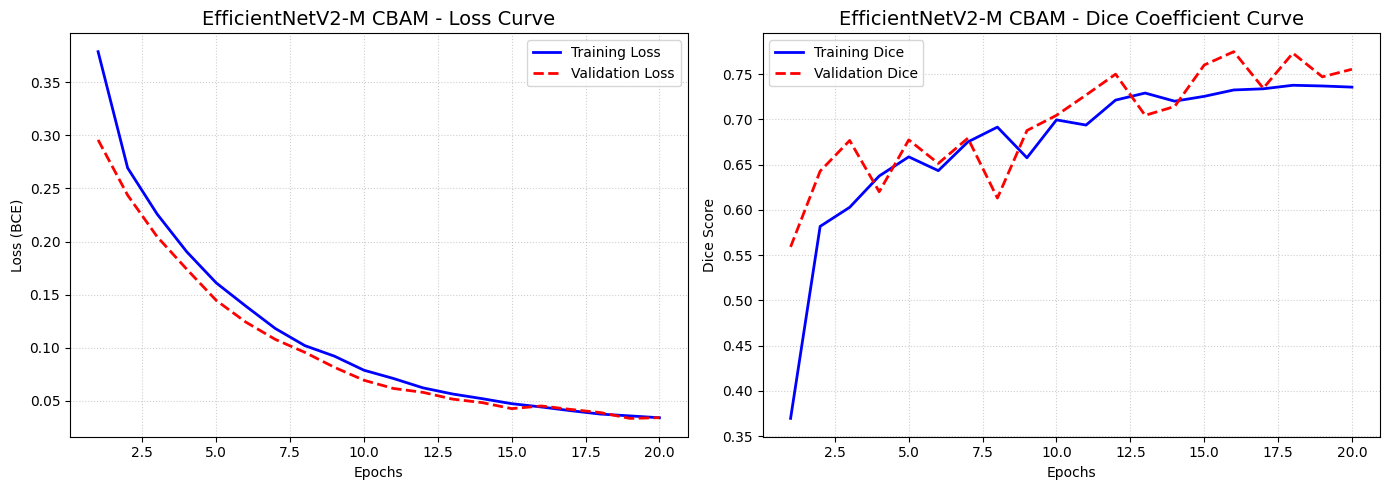

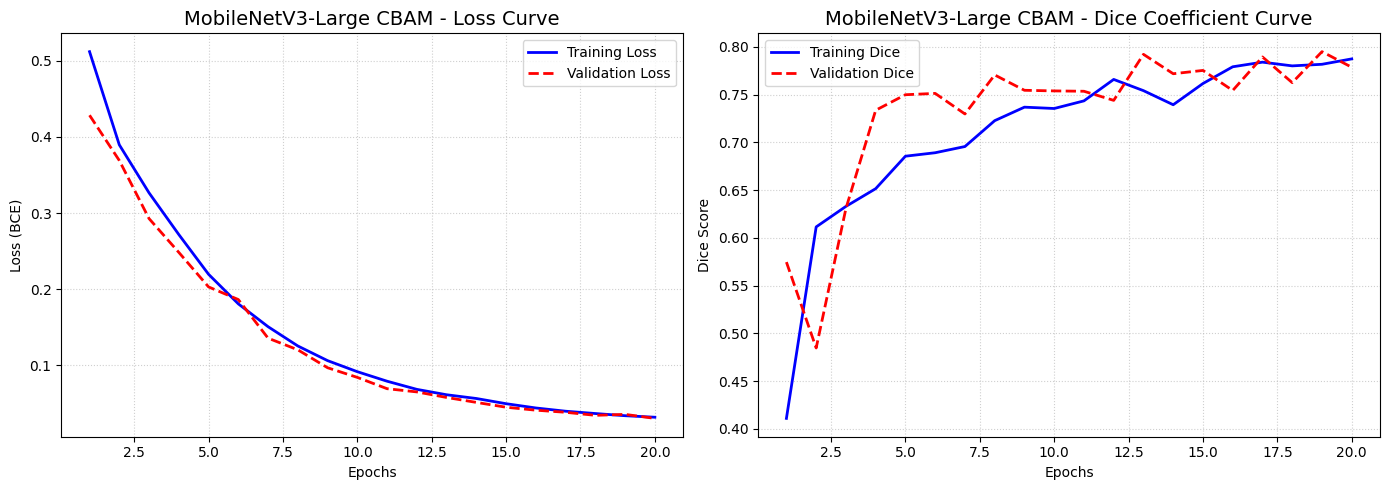

In [7]:
def plot_training_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Plot Losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    plt.title(f'{model_name} - Loss Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (BCE)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # Plot Dice
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_dice'], 'b-', label='Training Dice', linewidth=2)
    plt.plot(epochs, history['val_dice'], 'r--', label='Validation Dice', linewidth=2)
    plt.title(f'{model_name} - Dice Coefficient Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Dice Score')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(eff_history, "EfficientNetV2-M CBAM")
plot_training_curves(mob_history, "MobileNetV3-Large CBAM")

# 7. Prediction & Tumor Visualizer
Draws a batch of images and displays exactly where the model thinks the tumor is compared to ground truth.

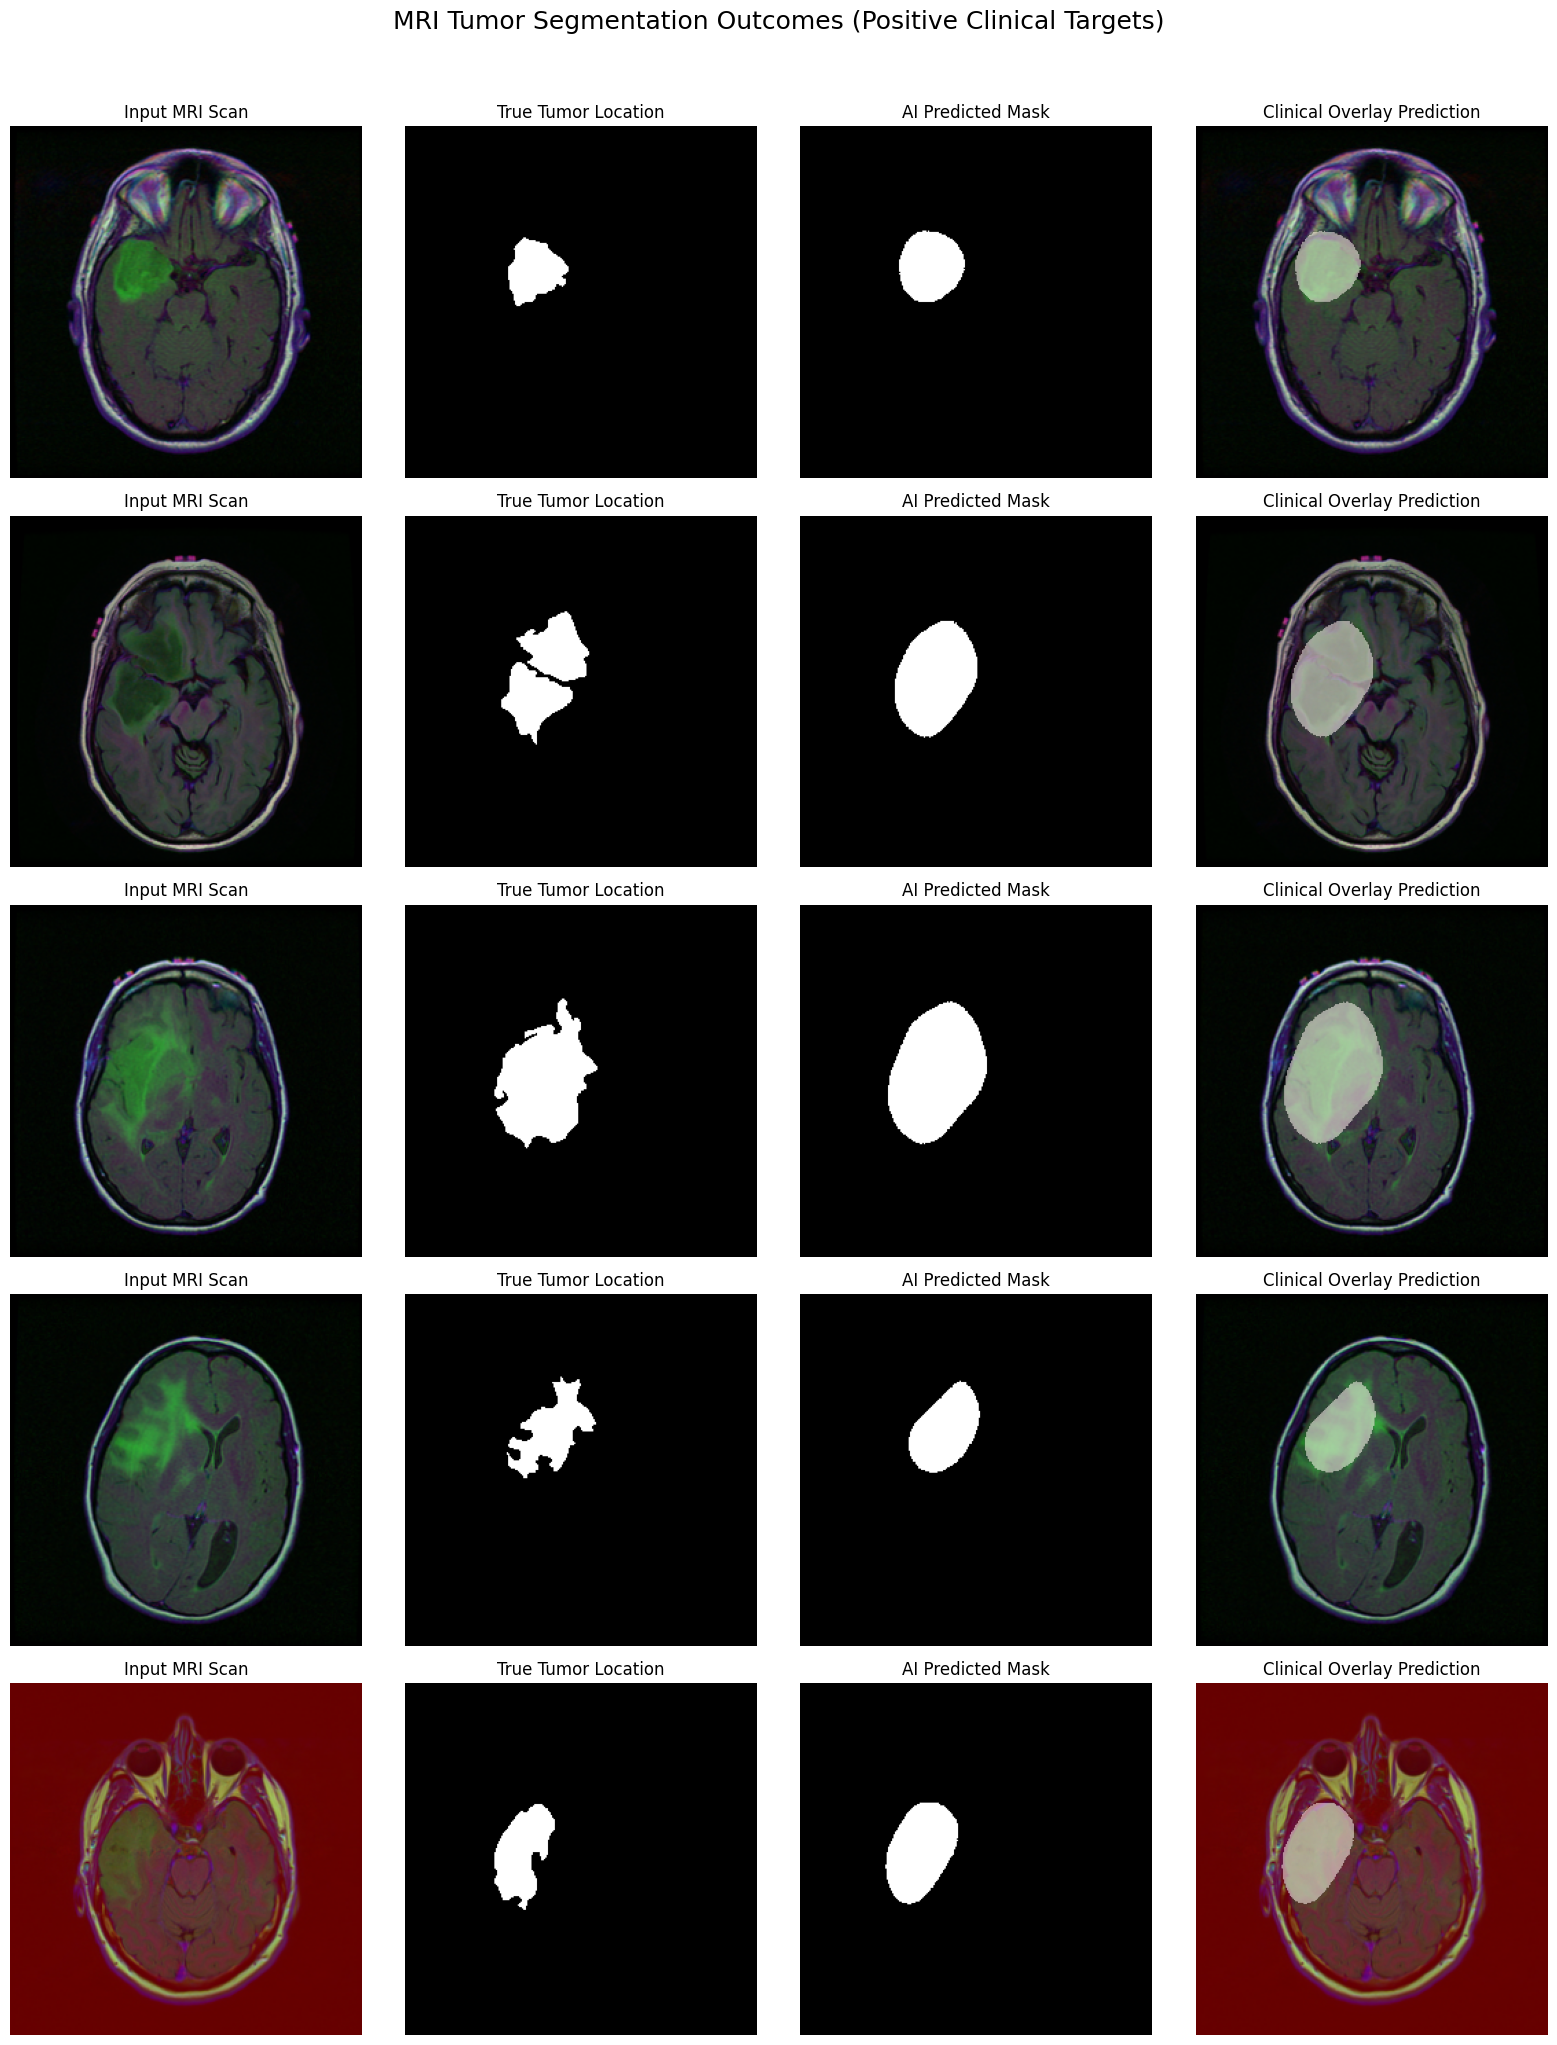

In [17]:
def visualize_tumor_predictions(eff_model, mob_model, dataloader, num_images=5):
    eff_model.eval()
    mob_model.eval()
    
    vis_images = []
    vis_true_masks = []
    vis_pred_masks = []
    
    with torch.no_grad():
        for images, masks in dataloader:
            images_dev = images.to(device)
            
            eff_probs = torch.sigmoid(eff_model(images_dev))
            mob_probs = torch.sigmoid(mob_model(images_dev))
            ensemble_probs = (0.7 * eff_probs) + (0.3 * mob_probs)
            preds = (ensemble_probs > 0.5).float()
            
            for i in range(images.size(0)):
                if masks[i].sum() > 50:
                    if len(vis_images) < num_images:
                        vis_images.append(images[i])
                        vis_true_masks.append(masks[i])
                        vis_pred_masks.append(preds[i].cpu())
            
            if len(vis_images) >= num_images:
                break

    if len(vis_images) < num_images:
        print(f"Warning: Only found {len(vis_images)} tumor slices. Displaying batch defaults.")
        images, masks = next(iter(dataloader))
        
    fig, axes = plt.subplots(num_images, 4, figsize=(16, 4 * num_images))
    fig.suptitle("MRI Tumor Segmentation Outcomes (Positive Clinical Targets)", fontsize=18, y=1.02)
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i in range(num_images):
        img = vis_images[i] * std + mean
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()
        
        true_mask = vis_true_masks[i].squeeze().numpy()
        pred_mask = vis_pred_masks[i].squeeze().numpy()
        
        ax = axes[i, 0]
        ax.imshow(img)
        ax.set_title("Input MRI Scan")
        ax.axis('off')
        
        ax = axes[i, 1]
        ax.imshow(true_mask, cmap='bone')
        ax.set_title("True Tumor Location")
        ax.axis('off')
        
        ax = axes[i, 2]
        ax.imshow(pred_mask, cmap='bone')
        ax.set_title("AI Predicted Mask")
        ax.axis('off')
        
        ax = axes[i, 3]
        ax.imshow(img)
        overlay = np.ma.masked_where(pred_mask == 0, pred_mask)
        ax.imshow(overlay, cmap='Reds', alpha=0.55)
        ax.set_title("Clinical Overlay Prediction")
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_tumor_predictions(eff_model, mob_model, test_loader, num_images=5)